# Q-Learning and G-Learning (Entropy-Regularised Q)

Compares two value-based TD control algorithms on the Fox (2016) 8x8 Gridworld.

| Algorithm | Bellman target | Key addition |
|-----------|---------------|-------------|
| **Q-learning** | `cost + gamma * min_a Q[s',a]` | — |
| **G-learning** | `cost + gamma * V_er[s']` (softmin) | beta schedule |

All hyperparameters come from `experiments/configs/default.yaml`.
Figures are saved to `report/figures/`.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from experiments.run_all import (
    load_config, run_algorithm, run_episode,
    _make_q_learning, _make_g_learning,
)
from environment.gridworld import GridWorldEnv
from utils.plotting import (
    plot_multi_curves,
    plot_value_heatmap, plot_vstar_heatmap,
    plot_policy_arrows, plot_summary_bar, save_figure,
)
from utils.metrics import V_STAR, policy_eval_error

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

## 0. Hyperparameters

In [2]:
cfg = load_config()

print('Environment')
print(f"  gamma          = {cfg['environment']['gamma']}")
print(f"  n_episodes     = {cfg['environment']['n_episodes']}")
print(f"  n_runs         = {cfg['environment']['n_runs']}")
print(f"  max_steps/ep   = {cfg['environment']['max_steps_per_episode']}")
print()
print('Learning rate')
print(f"  omega          = {cfg['learning_rate']['omega']}  (alpha = 1/n^omega)")
print()
print('Exploration')
print(f"  epsilon_start  = {cfg['exploration']['epsilon_start']}")
print(f"  epsilon_decay  = {cfg['exploration']['epsilon_decay']} per step")
print()
print('G-learning')
print(f"  beta_min       = {cfg['entropy_q']['beta_min']}")
print(f"  beta_max       = {cfg['entropy_q']['beta_max']}")

Environment
  gamma          = 0.85
  n_episodes     = 1500
  n_runs         = 10
  max_steps/ep   = 300

Learning rate
  omega          = 0.8  (alpha = 1/n^omega)

Exploration
  epsilon_start  = 0.4
  epsilon_decay  = 0.9 per step

G-learning
  beta_min       = 0.1
  beta_max       = 7.0


## 1. Running the Experiments

We use 3 independent runs here for speed. The full 10-run results live in
`experiments/results/` after you run `python experiments/run_all.py`.

Each run gets a distinct RNG seed, so the shaded bands reflect genuine
run-to-run variance, not sampling noise from a single trajectory.

In [3]:
# 3 runs for quick exploration; bump to cfg['environment']['n_runs'] for final results
nb_cfg = {**cfg, 'environment': {**cfg['environment'], 'n_runs': 3}}

In [4]:
print('Running Q-learning ...')
ql_results = run_algorithm('q_learning', _make_q_learning, nb_cfg, verbose=True)

Running Q-learning ...


16:18:45  INFO      q_learning              run 1/3  abs_err(final)=0.0823  1.1s
16:18:46  INFO      q_learning              run 2/3  abs_err(final)=0.0945  1.8s
16:18:47  INFO      q_learning              run 3/3  abs_err(final)=0.0975  2.5s


In [5]:
print('Running G-learning ...')
gl_results = run_algorithm('g_learning', _make_g_learning, nb_cfg, verbose=True)

Running G-learning ...


16:18:56  INFO      g_learning              run 1/3  abs_err(final)=0.0876  7.4s
16:19:04  INFO      g_learning              run 2/3  abs_err(final)=0.0808  15.2s
16:19:11  INFO      g_learning              run 3/3  abs_err(final)=0.0856  22.6s


## 2. Learning Curves

Three metrics are tracked:

* **Absolute relative error** `mean |V_est - V*| / V*` — convergence speed.
* **Signed relative error** `mean (V_est - V*) / V*` — optimism/pessimism.
* **Policy eval error** — error of the value of the induced greedy policy,
  recorded every 50 episodes (requires a full policy evaluation solve).

Shaded regions = mean +/- 1 std across runs.

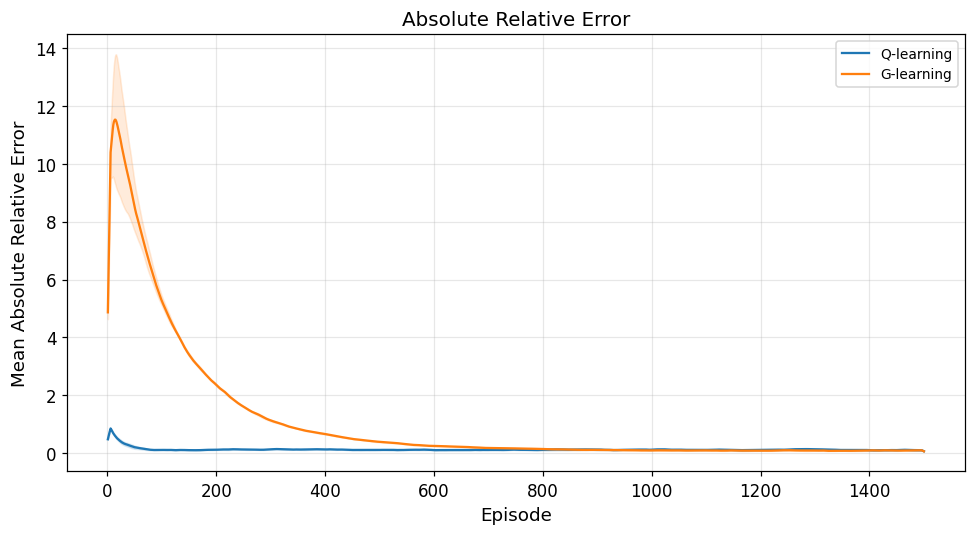

In [6]:
results_map = {'Q-learning': ql_results, 'G-learning': gl_results}

fig = plot_multi_curves(
    results_map,
    metric='abs_err',
    title='Absolute Relative Error',
    smooth=10,
)
save_figure(fig, '01_abs_err_ql_gl')
plt.show()

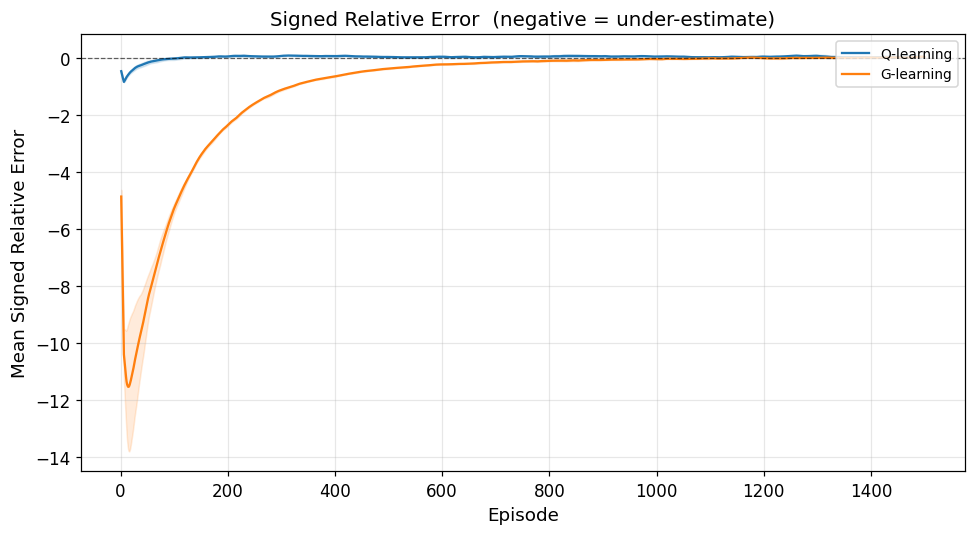

In [7]:
fig = plot_multi_curves(
    results_map,
    metric='signed_err',
    title='Signed Relative Error  (negative = under-estimate)',
    smooth=10,
)
for ax in fig.axes:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
save_figure(fig, '01_signed_err_ql_gl')
plt.show()

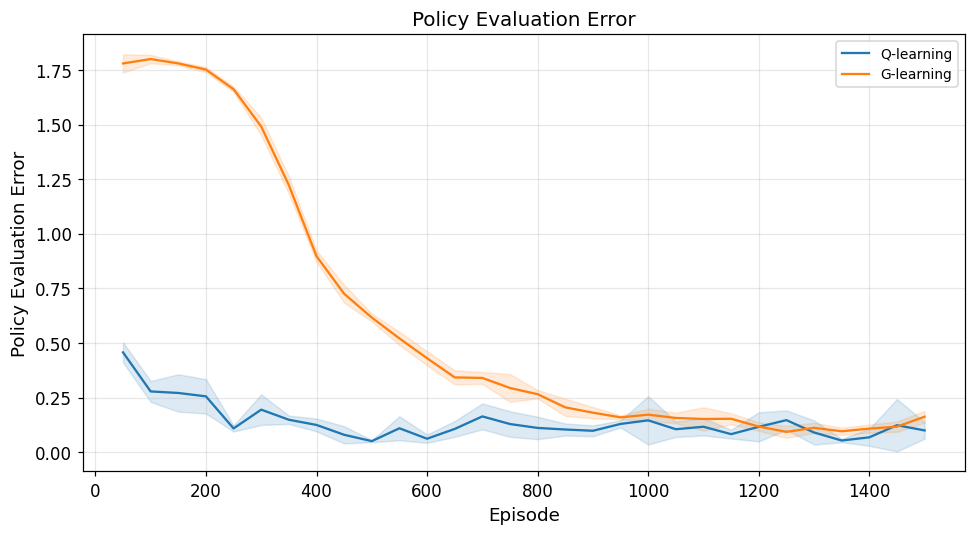

In [8]:
fig = plot_multi_curves(
    results_map,
    metric='policy_err',
    title='Policy Evaluation Error',
)
save_figure(fig, '01_policy_err_ql_gl')
plt.show()

## 3. Value Function Heatmaps

We train one agent per algorithm for the full 1500 episodes, then compare
the learned V(s) against the ground-truth V*(s).

* Gray cells = blocked/invalid states.
* Gold cell (G) = terminal state (zero cost, absorbing).

In [9]:
n_eps  = cfg['environment']['n_episodes']
max_st = cfg['environment']['max_steps_per_episode']

# Train Q-learning agent
q_agent = _make_q_learning(np.random.default_rng(42), cfg)
q_env   = GridWorldEnv(np.random.default_rng(43))
for ep in range(n_eps):
    run_episode(q_agent, q_env, max_st, ep)
V_ql  = q_agent.get_value_estimate()
pi_ql = q_agent.get_policy()
print(f'Q-learning  policy_err = {policy_eval_error(pi_ql):.4f}')

# Train G-learning agent (same seed for fair comparison)
g_agent = _make_g_learning(np.random.default_rng(42), cfg)
g_env   = GridWorldEnv(np.random.default_rng(43))
for ep in range(n_eps):
    run_episode(g_agent, g_env, max_st, ep)
V_gl  = g_agent.get_value_estimate()
pi_gl = g_agent.get_policy()
print(f'G-learning  policy_err = {policy_eval_error(pi_gl):.4f}')

Q-learning  policy_err = 0.0447
G-learning  policy_err = 0.1259


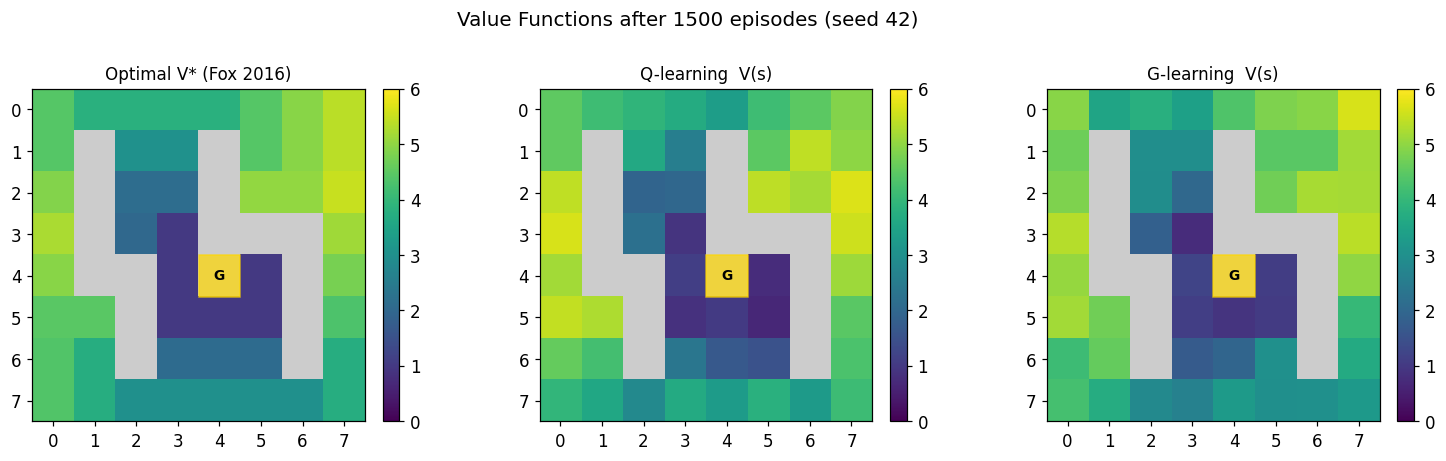

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_vstar_heatmap(ax=axes[0])
plot_value_heatmap(V_ql, title='Q-learning  V(s)', ax=axes[1], vmin=0, vmax=6)
plot_value_heatmap(V_gl, title='G-learning  V(s)', ax=axes[2], vmin=0, vmax=6)
fig.suptitle('Value Functions after 1500 episodes (seed 42)', fontsize=13, y=1.02)
fig.tight_layout()
save_figure(fig, '01_value_heatmaps')
plt.show()

## 4. Policy Visualisation

Each cell shows the highest-probability action at that state.
Arrow key: up N, NE, right E, SE, down S, SW, left W, NW, dot Stay.

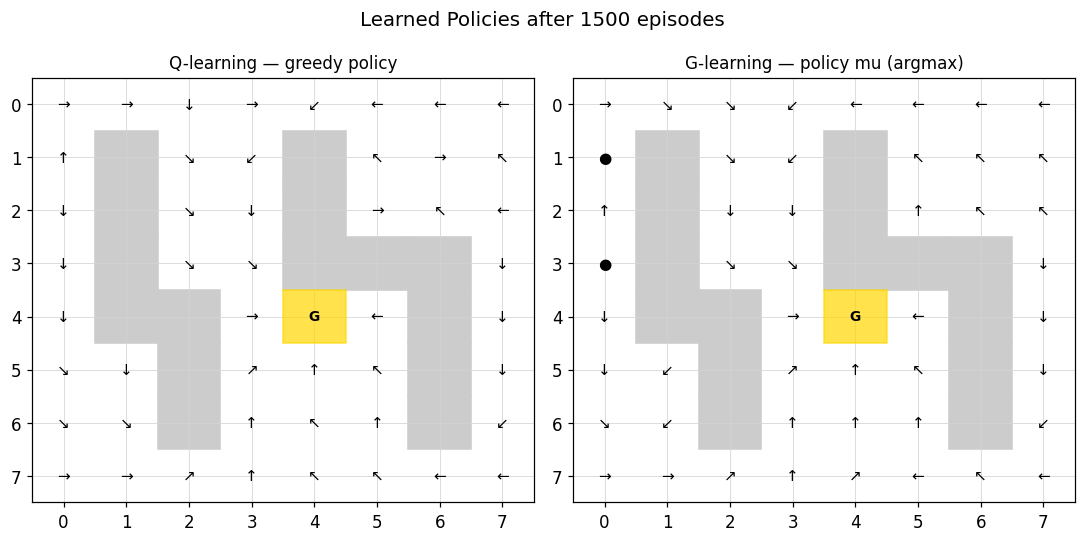

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_policy_arrows(pi_ql, title='Q-learning — greedy policy', ax=axes[0])
plot_policy_arrows(pi_gl, title='G-learning — policy mu (argmax)', ax=axes[1])
fig.suptitle('Learned Policies after 1500 episodes', fontsize=13)
fig.tight_layout()
save_figure(fig, '01_policy_arrows')
plt.show()

## 5. G-learning: Beta Schedule

The temperature beta controls how concentrated the softmin policy mu is.

* **Low beta (early)**: mu is near-uniform; G-learning resembles Q-learning.
* **High beta (late)**: mu is sharply peaked on the min-Q action.

The schedule is linear: `beta_t = beta_min + t * (beta_max - beta_min) / n_episodes`.

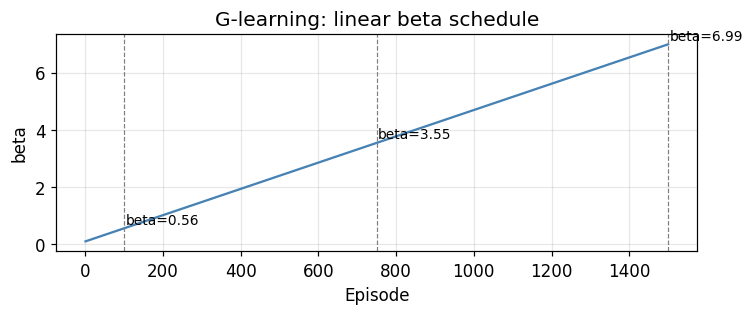

beta at ep  100: 0.5554
beta at ep  750: 3.5454
beta at ep 1500: 6.9954


In [12]:
beta_min   = cfg['entropy_q']['beta_min']
beta_max   = cfg['entropy_q']['beta_max']
eps_range  = np.arange(n_eps)
beta_sched = beta_min + eps_range * (beta_max - beta_min) / n_eps

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(eps_range + 1, beta_sched, color='steelblue')
for mark in [99, 749, 1498]:
    ax.axvline(mark + 1, color='gray', linestyle='--', linewidth=0.8)
    ax.text(mark + 5, beta_sched[mark] + 0.15,
            f'beta={beta_sched[mark]:.2f}', fontsize=9)
ax.set_xlabel('Episode')
ax.set_ylabel('beta')
ax.set_title('G-learning: linear beta schedule')
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '01_beta_schedule')
plt.show()

print(f'beta at ep  100: {beta_sched[99]:.4f}')
print(f'beta at ep  750: {beta_sched[749]:.4f}')
print(f'beta at ep 1500: {beta_sched[1499]:.4f}')

## 6. Summary

Q-learning       abs_err=0.0914+/-0.0065  policy_err=0.0998+/-0.0380
G-learning       abs_err=0.0847+/-0.0028  policy_err=0.1626+/-0.0271


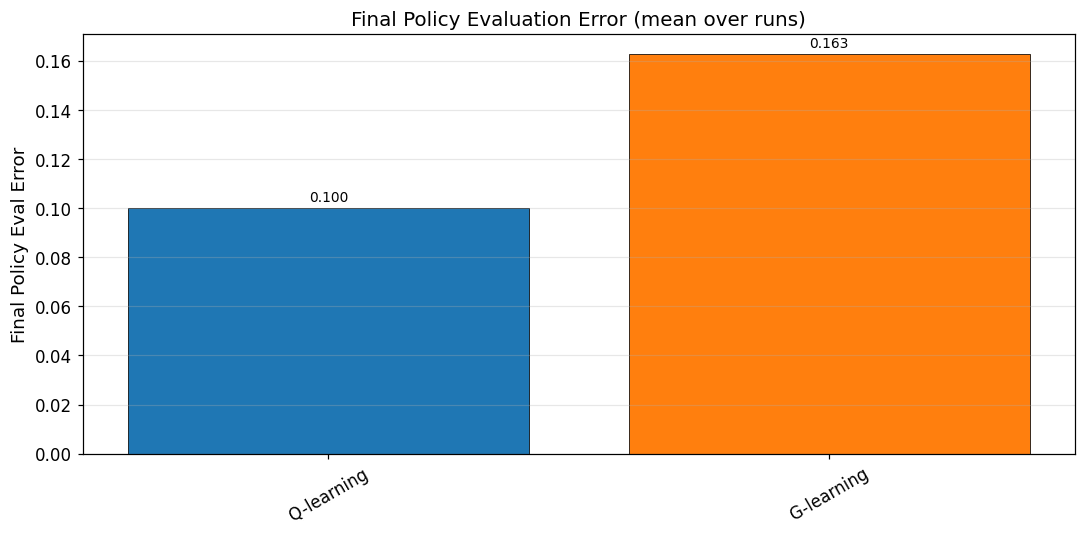

In [13]:
def final_stats(res, name):
    abs_m = res['abs_err'][:, -1].mean()
    abs_s = res['abs_err'][:, -1].std()
    pol_m = res['policy_err'][:, -1].mean()
    pol_s = res['policy_err'][:, -1].std()
    print(f'{name:<15}  abs_err={abs_m:.4f}+/-{abs_s:.4f}  '
          f'policy_err={pol_m:.4f}+/-{pol_s:.4f}')
    return pol_m

pol_ql = final_stats(ql_results, 'Q-learning')
pol_gl = final_stats(gl_results, 'G-learning')

fig = plot_summary_bar(
    {'Q-learning': pol_ql, 'G-learning': pol_gl},
    title='Final Policy Evaluation Error (mean over runs)',
)
save_figure(fig, '01_final_bar')
plt.show()

## 7. Hyperparameter Tuning

We sweep the most impactful parameters for each algorithm, fixing all others
at their defaults. Metric: mean final `policy_err` across 3 runs (1500 episodes each).

In [ ]:
from algorithms.q_learning import QLearningAgent
from algorithms.entropy_reg_q import EntropyRegQLearningAgent

TUNE_RUNS = 3
GAMMA  = cfg['environment']['gamma']
N_EPS  = cfg['environment']['n_episodes']
MAX_ST = cfg['environment']['max_steps_per_episode']

def run_sweep(factory, n_runs=TUNE_RUNS, n_eps=N_EPS, max_steps=MAX_ST, base_seed=0):
    """Return mean final policy_err across n_runs."""
    from utils.metrics import policy_eval_error
    errors = []
    for run in range(n_runs):
        rng_a = np.random.default_rng(base_seed + run * 1000)
        rng_e = np.random.default_rng(base_seed + run * 1000 + 1)
        agent = factory(rng_a)
        env   = GridWorldEnv(rng_e)
        for ep in range(n_eps):
            run_episode(agent, env, max_steps, ep)
        errors.append(policy_eval_error(agent.get_policy()))
    return float(np.mean(errors))

### 7a. Q-Learning: Learning-Rate Exponent ω

α_t = n_t(s,a)^{−ω}. Higher ω decays the learning rate faster.
We sweep ω ∈ {0.6, 0.7, 0.8, 0.9, 1.0}.

In [ ]:
omega_vals = [0.6, 0.7, 0.8, 0.9, 1.0]
eps_start  = cfg['exploration']['epsilon_start']
eps_decay  = cfg['exploration']['epsilon_decay']

omega_errors_ql = {}
for om in omega_vals:
    err = run_sweep(lambda rng, om=om: QLearningAgent(
        rng, GAMMA, omega=om,
        epsilon_start=eps_start, epsilon_decay=eps_decay))
    omega_errors_ql[om] = err
    print(f'  omega={om:.1f}  policy_err={err:.4f}')

best_omega_ql = min(omega_errors_ql, key=omega_errors_ql.get)
print(f'\nBest omega (Q-learning): {best_omega_ql}  '  
      f'(policy_err={omega_errors_ql[best_omega_ql]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(omega_errors_ql.keys()), list(omega_errors_ql.values()), 'o-')
ax.axvline(best_omega_ql, color='red', linestyle='--', alpha=0.6, label=f'best ω={best_omega_ql}')
ax.set_xlabel('ω (LR exponent)')
ax.set_ylabel('Final policy_err')
ax.set_title('Q-Learning: LR Exponent Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '01_tune_ql_omega')
plt.show()

### 7b. Q-Learning: Initial Exploration ε₀

Fixes ω at the best value found above; sweeps ε₀ ∈ {0.1, 0.2, 0.4, 0.6, 0.8}.

In [ ]:
eps_vals = [0.1, 0.2, 0.4, 0.6, 0.8]

eps_errors_ql = {}
for es in eps_vals:
    err = run_sweep(lambda rng, es=es: QLearningAgent(
        rng, GAMMA, omega=best_omega_ql,
        epsilon_start=es, epsilon_decay=eps_decay))
    eps_errors_ql[es] = err
    print(f'  epsilon_start={es:.1f}  policy_err={err:.4f}')

best_eps_ql = min(eps_errors_ql, key=eps_errors_ql.get)
print(f'\nBest epsilon_start (Q-learning): {best_eps_ql}  '
      f'(policy_err={eps_errors_ql[best_eps_ql]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(eps_errors_ql.keys()), list(eps_errors_ql.values()), 'o-')
ax.axvline(best_eps_ql, color='red', linestyle='--', alpha=0.6, label=f'best ε₀={best_eps_ql}')
ax.set_xlabel('ε₀ (initial epsilon)')
ax.set_ylabel('Final policy_err')
ax.set_title('Q-Learning: Initial Epsilon Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '01_tune_ql_eps')
plt.show()

### 7c. G-Learning: Final Temperature β_max

Controls how greedy the softmin policy is at convergence. Swept over {3, 5, 7, 10, 15}.

In [ ]:
beta_max_vals = [3.0, 5.0, 7.0, 10.0, 15.0]
beta_min_fixed = cfg['entropy_q']['beta_min']

betamax_errors = {}
for bmax in beta_max_vals:
    err = run_sweep(lambda rng, bmax=bmax: EntropyRegQLearningAgent(
        rng, GAMMA, omega=best_omega_ql,
        epsilon_start=best_eps_ql, epsilon_decay=eps_decay,
        beta_min=beta_min_fixed, beta_max=bmax,
        n_episodes=N_EPS))
    betamax_errors[bmax] = err
    print(f'  beta_max={bmax:.1f}  policy_err={err:.4f}')

best_beta_max = min(betamax_errors, key=betamax_errors.get)
print(f'\nBest beta_max (G-learning): {best_beta_max}  '
      f'(policy_err={betamax_errors[best_beta_max]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(betamax_errors.keys()), list(betamax_errors.values()), 'o-')
ax.axvline(best_beta_max, color='red', linestyle='--', alpha=0.6, label=f'best β_max={best_beta_max}')
ax.set_xlabel('β_max')
ax.set_ylabel('Final policy_err')
ax.set_title('G-Learning: β_max Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '01_tune_gl_betamax')
plt.show()

### 7d. G-Learning: Initial Temperature β_min

Controls how exploratory the softmin policy is at episode 1. Swept over {0.01, 0.05, 0.1, 0.5, 1.0}.

In [ ]:
beta_min_vals = [0.01, 0.05, 0.1, 0.5, 1.0]

betamin_errors = {}
for bmin in beta_min_vals:
    err = run_sweep(lambda rng, bmin=bmin: EntropyRegQLearningAgent(
        rng, GAMMA, omega=best_omega_ql,
        epsilon_start=best_eps_ql, epsilon_decay=eps_decay,
        beta_min=bmin, beta_max=best_beta_max,
        n_episodes=N_EPS))
    betamin_errors[bmin] = err
    print(f'  beta_min={bmin:.3f}  policy_err={err:.4f}')

best_beta_min = min(betamin_errors, key=betamin_errors.get)
print(f'\nBest beta_min (G-learning): {best_beta_min}  '
      f'(policy_err={betamin_errors[best_beta_min]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(list(betamin_errors.keys()), list(betamin_errors.values()), 'o-')
ax.axvline(best_beta_min, color='red', linestyle='--', alpha=0.6, label=f'best β_min={best_beta_min}')
ax.set_xlabel('β_min (log scale)')
ax.set_ylabel('Final policy_err')
ax.set_title('G-Learning: β_min Sweep')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, '01_tune_gl_betamin')
plt.show()

In [ ]:
print('=' * 50)
print('TUNED HYPERPARAMETERS — update default.yaml with these values')
print('=' * 50)
print(f'  learning_rate.omega        : {best_omega_ql}')
print(f'  exploration.epsilon_start  : {best_eps_ql}')
print(f'  entropy_q.beta_max         : {best_beta_max}')
print(f'  entropy_q.beta_min         : {best_beta_min}')

## Discussion

**Q-learning** uses the hard minimum over Q as its Bellman target.
This produces a pessimistic (under-estimating) bias early in training —
visible as a negative signed error — because rare low-cost transitions
propagate backward faster than high-cost ones.

**G-learning** uses a softmin (entropy-regularised) value as its target.
When beta is low (early episodes), the softmin is nearly uniform and
G-learning behaves like standard Q-learning. As beta rises, the target
sharpens. The gradual transition can smooth out the noise caused by rare
low-cost transitions and sometimes leads to better-calibrated early estimates.

Both algorithms share identical exploration (epsilon-greedy), learning rate
schedule (count-based 1/n^omega), and discount (gamma=0.85). The *only*
difference is the Bellman target.